In [ ]:
from keras.layers import Input, Conv2D, BatchNormalization, ReLU, MaxPooling2D, Concatenate, GlobalMaxPooling2D, Dropout, Dense, Lambda, Reshape, Activation, Multiply, Add
from keras.applications import VGG16, DenseNet121, InceptionV3, VGG19, Xception, ResNet50
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from keras.layers import Input, Dropout, Dense, GlobalAveragePooling2D
from tool import load_data, draw_curve, draw_matrix, TimeHistory
from keras.models import Sequential, Model
from keras import backend as K
from tensorflow import keras
import tensorflow as tf
import numpy as np
import sys

2024-10-18 16:14:51.163183: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


100%|██████████| 1000/1000 [00:00<00:00, 10559.07it/s]


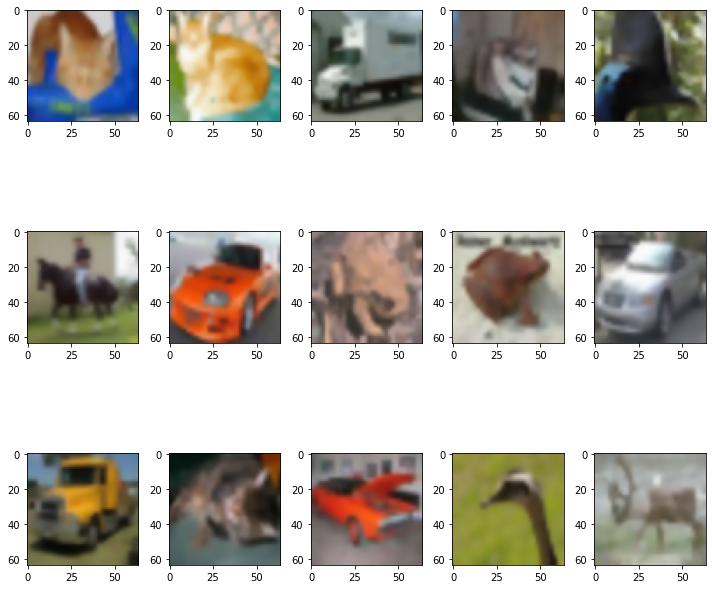

(10000, 64, 64, 3)
(50000, 64, 64, 3)
(10000, 10)
(50000, 10)


In [2]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
data_path = '/root/autodl-tmp/cifar10/original'
image_size = 64
x_train, x_test, y_train, y_test = load_data(data_path, labels, image_size)

In [7]:
def block(inputs, filters):

    m = Conv2D(filters, 1, padding='same')(inputs)
    m = BatchNormalization()(m)
    m = ReLU()(m)

    a = Conv2D(filters, 3, padding='same')(inputs)
    a = BatchNormalization()(a)
    a = ReLU()(a)
    
    b = Concatenate()([m, a])

    d = Conv2D(filters * 2, 3, padding='same')(b)
    d = BatchNormalization()(d)
    d = ReLU()(d)

    d = Conv2D(filters * 2, 3, padding='same')(d)
    d = BatchNormalization()(d)
    d = ReLU()(d)
    
    x = Concatenate()([b, d])

    m = Conv2D(filters*4, 1, padding='same')(inputs)
    m = BatchNormalization()(m)
    m = ReLU()(m)
    
    x = Add()([m, x])

    y = Conv2D(filters*2, 1)(x)
    y = BatchNormalization()(y)
    y = ReLU()(y)
    
    return y

def load_model():
    
    K.clear_session()
    inputs = Input(shape=(image_size, image_size, 3))

    net = DenseNet121(weights='imagenet', include_top=False, input_tensor=inputs)

    x = net.get_layer('pool4_conv').output
    x = block(x, 512)  

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(10, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=x)
    
    return model

In [8]:
model = load_model()
adam = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 64, 64, 3)]  0           []                               
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 70, 70, 3)   0           ['input_1[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 32, 32, 64)   9408        ['zero_padding2d[0][0]']         
                                                                                                  
 conv1/bn (BatchNormalization)  (None, 32, 32, 64)   256         ['conv1/conv[0][0]']             
                                                                                              

In [9]:
tensorboard = TensorBoard(log_dir = 'logs')
checkpoint = ModelCheckpoint(filepath='model-cifar10.h5',
                             monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.3, patience = 5, min_delta = 0.001,
                              mode='auto',verbose=1)
time_callback = TimeHistory()
history = model.fit(x_train,y_train,validation_split=0.1, epochs =50, verbose=1, batch_size=36,
                   callbacks=[tensorboard,checkpoint,reduce_lr, time_callback])

Epoch 1/50
 537/1250 [===========>..................] - ETA: 19s - loss: 0.6437 - accuracy: 0.7822

1249/1250 [============================>.] - ETA: 0s - loss: 0.5063 - accuracy: 0.8286
Epoch 1: val_accuracy improved from -inf to 0.88600, saving model to model-cifar10.h5
Epoch 1: 46.08 seconds
1250/1250 [==============================] - 46s 32ms/step - loss: 0.5060 - accuracy: 0.8287 - val_loss: 0.3404 - val_accuracy: 0.8860 - lr: 1.0000e-04
Epoch 2/50
1249/1250 [============================>.] - ETA: 0s - loss: 0.2314 - accuracy: 0.9207
Epoch 2: val_accuracy improved from 0.88600 to 0.89660, saving model to model-cifar10.h5
Epoch 2: 36.80 seconds
1250/1250 [==============================] - 37s 29ms/step - loss: 0.2313 - accuracy: 0.9208 - val_loss: 0.3068 - val_accuracy: 0.8966 - lr: 1.0000e-04
Epoch 3/50
1250/1250 [==============================] - ETA: 0s - loss: 0.1432 - accuracy: 0.9505
Epoch 3: val_accuracy improved from 0.89660 to 0.90760, saving model to model-cifar10.h5
Epoch 3: 37.14 seconds
1250/1250 [==============================] - 37s 30ms/step - loss: 0.1432 - accu

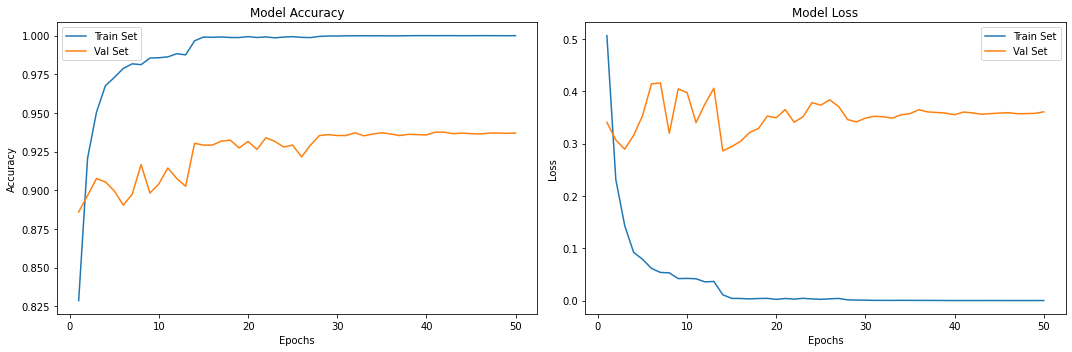

313/313 [==============================] - 4s 12ms/step - loss: 0.3266 - accuracy: 0.9369
Test Accuracy:  93.69
              precision    recall  f1-score   support

    airplane     0.9502    0.9550    0.9526      1000
  automobile     0.9602    0.9660    0.9631      1000
        bird     0.9473    0.9170    0.9319      1000
         cat     0.8738    0.8520    0.8628      1000
        deer     0.9422    0.9450    0.9436      1000
         dog     0.8816    0.8790    0.8803      1000
        frog     0.9516    0.9640    0.9578      1000
       horse     0.9542    0.9580    0.9561      1000
        ship     0.9474    0.9730    0.9600      1000
       truck     0.9581    0.9600    0.9590      1000

    accuracy                         0.9369     10000
   macro avg     0.9367    0.9369    0.9367     10000
weighted avg     0.9367    0.9369    0.9367     10000



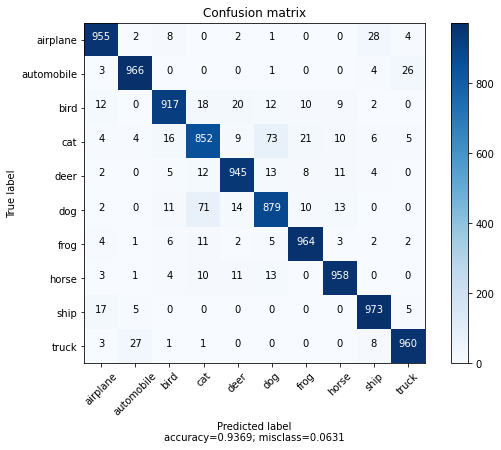

In [10]:
draw_curve(history)
pred = model.predict(x_test)
pred = np.argmax(pred,axis=1)
y_test_new = np.argmax(y_test,axis=1)
loss,acc = model.evaluate(x_test,y_test,verbose = 1)
draw_matrix(labels, y_test_new, pred, acc)